In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import loadtxt,sqrt,zeros,array,exp
from numpy import linalg
from scipy.integrate import odeint

In [2]:
# implementation of commutators, note that a reshape is necessary since odeint only accepts 1D arrays
def commutator(A,B):
    return np.matmul(A,B)-np.matmul(B,A)

def commutator_reshape(A,B,Nrows):
    A_reshape = np.reshape(A,(Nrows,Nrows))
    B_reshape = np.reshape(B,(Nrows,Nrows))
    return np.matmul(A_reshape,B_reshape)-np.matmul(B_reshape,A_reshape)

def commutator_reshape_coupled(A,B,Nrows):
    A_reshape = np.reshape(A,(2*Nrows,2*Nrows))
    B_reshape = np.reshape(B,(2*Nrows,2*Nrows))
    return np.matmul(A_reshape,B_reshape)-np.matmul(B_reshape,A_reshape)

In [31]:
C = np.matrix('1 2; 3 4')

In [32]:
C

matrix([[1, 2],
        [3, 4]])

In [41]:
D = C.flatten()
D

matrix([[1, 2, 3, 4]])

In [40]:
type(D)

numpy.matrix

In [3]:
# computation of deuteron binding energy via diagonalization
def solve_deuteron(V00, V02, V20, V22, Nrows):  
    hbarc = 197.326
    M = 939
    units_factor = hbarc * hbarc / M
    Hmat = zeros([2*Nrows,2*Nrows],float)
    for i in range(Nrows):
        Hmat[i,i] += units_factor * mesh_points[i] * mesh_points[i]
        Hmat[i + Nrows,i + Nrows] += units_factor * mesh_points[i] * mesh_points[i] #Kinetic terms are diagonal, therefore only placed
                                                                                    # along i = j in the Hmatrix

        for j in range(Nrows):
            Hmat[i,j] += units_factor * V00[i,j]
            Hmat[i,j + Nrows] += units_factor * V02[i,j]
            Hmat[i + Nrows,j] += units_factor * V20[i,j]
            Hmat[i + Nrows,j + Nrows] += units_factor * V22[i,j] #Place Potential values in every possible entry of the Hmatrix
    
    w, v = linalg.eig(Hmat) #solve for eigenvalues

    Hmat_diag = zeros([2*Nrows,2*Nrows],float)
    for k in range(len(w)):
        Hmat_diag[k, k] = w[k]

    idx = np.argsort(w) #sort eigenvalues so that we can extract the minimum value
    w = w[idx]

    return w[0], Hmat_diag

In [4]:
# read in files and get reference deuteron energy for unevolved interaction (fitted to experimental value)
potential_index = 2

# potential_index:
# 1: use EFT potential with 100 mesh points
# 2: use EFT potential with 50 mesh points
# 3: use AV18 potential with 200 mesh points
# 4: use AV18 potential with 80 mesh points    

if potential_index == 1:    
    file00 = "VNN_3S1_EFT.dat"
    file02 = "VNN_3SD1_EFT.dat"
    file20 = "VNN_3DS1_EFT.dat"
    file22 = "VNN_3D1_EFT.dat"
elif potential_index == 2: 
    file00 = "VNN_3S1_EFT_coarse.dat"
    file02 = "VNN_3SD1_EFT_coarse.dat"
    file20 = "VNN_3DS1_EFT_coarse.dat"
    file22 = "VNN_3D1_EFT_coarse.dat"
elif potential_index == 3:
    file00 = "VNN_3S1_AV18.dat"
    file02 = "VNN_3SD1_AV18.dat"
    file20 = "VNN_3DS1_AV18.dat"
    file22 = "VNN_3D1_AV18.dat"
elif potential_index == 4:
    file00 = "VNN_3S1_AV18_coarse.dat"
    file02 = "VNN_3SD1_AV18_coarse.dat"
    file20 = "VNN_3DS1_AV18_coarse.dat"
    file22 = "VNN_3D1_AV18_coarse.dat"

'''.dat files are sorted like this: first 100 columns are the weights (0) and the momenta (1) of the gauß-legendre integration.
Starting at column 101, row 1 is the incoming momentum, row 2 the outgoing momentum and row 3 the associated potential value for 
this specific momentum transfer'''

Nrows=mesh =np.genfromtxt(file00,dtype=(int),skip_header=0,max_rows=1)

mesh =np.genfromtxt(file00,dtype=(float,float),skip_header=1,max_rows=Nrows)
mesh_weights=mesh[:,0]
mesh_points=mesh[:,1]
mesh_points_coupled=zeros(2*Nrows,float)

Vdata00=np.genfromtxt(file00,dtype=(float,float,float),skip_header=Nrows+1,max_rows=Nrows*Nrows)
Vdata02=np.genfromtxt(file02,dtype=(float,float,float),skip_header=Nrows+1,max_rows=Nrows*Nrows)
Vdata20=np.genfromtxt(file20,dtype=(float,float,float),skip_header=Nrows+1,max_rows=Nrows*Nrows)
Vdata22=np.genfromtxt(file22,dtype=(float,float,float),skip_header=Nrows+1,max_rows=Nrows*Nrows)

Vmat00 = zeros([Nrows,Nrows],float)
Vmat02 = zeros([Nrows,Nrows],float)
Vmat20 = zeros([Nrows,Nrows],float)
Vmat22 = zeros([Nrows,Nrows],float)
Vmat = zeros([2*Nrows,2*Nrows],float)

Tmat = zeros([Nrows,Nrows],float)
Tmat_coupled = zeros([2*Nrows,2*Nrows],float)
PhaseSpace = zeros([Nrows,Nrows],float)
PhaseSpace_coupled = zeros([2*Nrows,2*Nrows],float)

for i in range(Nrows):
    Tmat[i,i] = mesh_points[i] * mesh_points[i]
    Tmat_coupled[i,i] = Tmat[i,i]
    Tmat_coupled[i+Nrows,i+Nrows] = Tmat[i,i]
    
    for j in range(Nrows):
        Vmat00[i,j] = 2.0/np.pi*sqrt(mesh_weights[i]) * sqrt(mesh_weights[j]) * mesh_points[i] * mesh_points[j] * Vdata00[i*Nrows+j][2]
        Vmat02[i,j] = 2.0/np.pi*sqrt(mesh_weights[i]) * sqrt(mesh_weights[j]) * mesh_points[i] * mesh_points[j] * Vdata02[i*Nrows+j][2]
        Vmat20[i,j] = 2.0/np.pi*sqrt(mesh_weights[i]) * sqrt(mesh_weights[j]) * mesh_points[i] * mesh_points[j] * Vdata20[i*Nrows+j][2]
        Vmat22[i,j] = 2.0/np.pi*sqrt(mesh_weights[i]) * sqrt(mesh_weights[j]) * mesh_points[i] * mesh_points[j] * Vdata22[i*Nrows+j][2]
        Vmat[i,j] = Vmat00[i,j]
        Vmat[i,j+Nrows] = Vmat02[i,j]
        Vmat[i+Nrows,j] = Vmat20[i,j]
        Vmat[i+Nrows,j+Nrows] = Vmat22[i,j]
        PhaseSpace[i,j] = 2.0/np.pi*sqrt(mesh_weights[i]) * sqrt(mesh_weights[j]) * mesh_points[i] * mesh_points[j]
        PhaseSpace_coupled[i,j] = PhaseSpace[i,j]
        PhaseSpace_coupled[i,j + Nrows] = PhaseSpace[i,j]
        PhaseSpace_coupled[i + Nrows,j] = PhaseSpace[i,j]
        PhaseSpace_coupled[i + Nrows,j + Nrows] = PhaseSpace[i,j]
             
Edeut = solve_deuteron(Vmat00, Vmat02, Vmat20, Vmat22, Nrows)[0];
print("E_gs = %.6f MeV" % Edeut)
solve_deuteron(Vmat00, Vmat02, Vmat20, Vmat22, Nrows)[1]

E_gs = -2.224363 MeV


array([[1.03550281e+03, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 1.03550281e+03, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.03049834e+03, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        3.41580262e-04, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 3.33042501e-04, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 9.23095219e-03]])

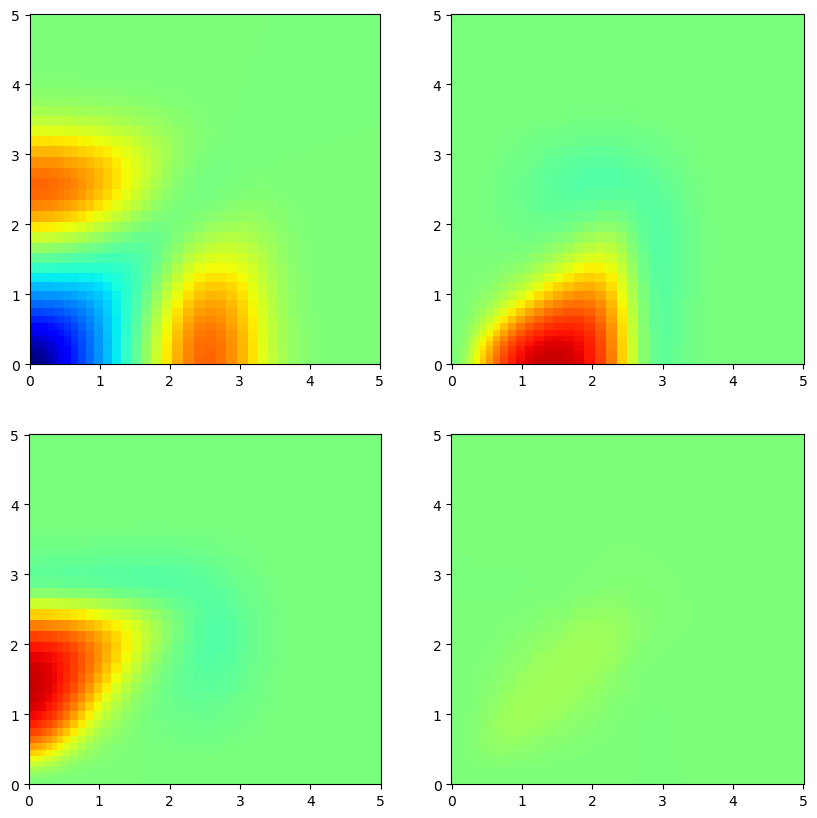

In [5]:
# plot initial matrix elements in coupled channels
maxindex = Nrows
fig, (ax) = plt.subplots(nrows=2,ncols=2,figsize=(10, 10))
maxabs = max(abs((Vmat/PhaseSpace_coupled)[:maxindex,:maxindex].min()),abs(abs((Vmat/PhaseSpace_coupled)[:maxindex,:maxindex].max())))
ax[0,0].set_aspect('equal')
im = ax[0,0].pcolormesh(mesh_points[:maxindex], mesh_points[:maxindex], (Vmat00/PhaseSpace)[:maxindex,:maxindex], vmin = -maxabs, vmax = maxabs, cmap='jet',rasterized=True)
im = ax[0,1].pcolormesh(mesh_points[:maxindex], mesh_points[:maxindex], (Vmat02/PhaseSpace)[:maxindex,:maxindex], vmin = -maxabs, vmax = maxabs, cmap='jet',rasterized=True)
im = ax[1,0].pcolormesh(mesh_points[:maxindex], mesh_points[:maxindex], (Vmat20/PhaseSpace)[:maxindex,:maxindex], vmin = -maxabs, vmax = maxabs, cmap='jet',rasterized=True)
im = ax[1,1].pcolormesh(mesh_points[:maxindex], mesh_points[:maxindex], (Vmat22/PhaseSpace)[:maxindex,:maxindex], vmin = -maxabs, vmax = maxabs, cmap='jet',rasterized=True)

In [ ]:
print(Vmat.shape) #2*N

(100, 100)


In [13]:
print(Tmat_coupled.shape)

(100, 100)


In [27]:
commutator(Tmat_coupled, Vmat);

In [26]:
commutator_reshape_coupled(Tmat_coupled, Vmat, Nrows);

In [30]:
print(commutator(Tmat_coupled, Vmat).shape)
print(commutator_reshape_coupled(Tmat_coupled, Vmat, Nrows).shape)

(100, 100)
(100, 100)


In [6]:
def SRGflow_derivative(Hflat, s, Tmat_coupled, Nrows): 

    eta = commutator_reshape_coupled(Tmat_coupled, Hflat, Nrows)
    diffH = commutator_reshape_coupled(eta, Hflat, Nrows)

    return diffH.flatten() 


In [17]:
#Initial value at s = 0
H_init = (Tmat_coupled + Vmat).flatten()

#Flow parameter array
s_steps = np.linspace(0, 0.1633, 50)

sol = odeint(SRGflow_derivative, H_init, s_steps, args=(Tmat_coupled, Nrows))

In [9]:
H_init_mat = H_init.reshape(2*Nrows, 2*Nrows)

In [10]:
H_final = sol[-1]
H_final_mat = H_final.reshape(2*Nrows, 2*Nrows)
V_final_mat = H_final_mat - Tmat_coupled


In [11]:
#Extract V00, V02, V20 and V22 from V_final_mat

Vmat00_final = zeros([Nrows,Nrows],float)
Vmat02_final = zeros([Nrows,Nrows],float)
Vmat20_final = zeros([Nrows,Nrows],float)
Vmat22_final = zeros([Nrows,Nrows],float)
for i in range(Nrows):
    
    for j in range(Nrows):

        Vmat00_final[i,j] = V_final_mat[i,j]
        Vmat02_final[i,j] = V_final_mat[i,j+Nrows]
        Vmat20_final[i,j] = V_final_mat[i+Nrows,j]
        Vmat22_final[i,j] = V_final_mat[i+Nrows,j+Nrows]


In [12]:
Edeut_final = solve_deuteron(Vmat00_final, Vmat02_final, Vmat20_final, Vmat22_final, Nrows)[0];
print("E_gs = %.6f MeV" % Edeut_final)

E_gs = -2.224358 MeV


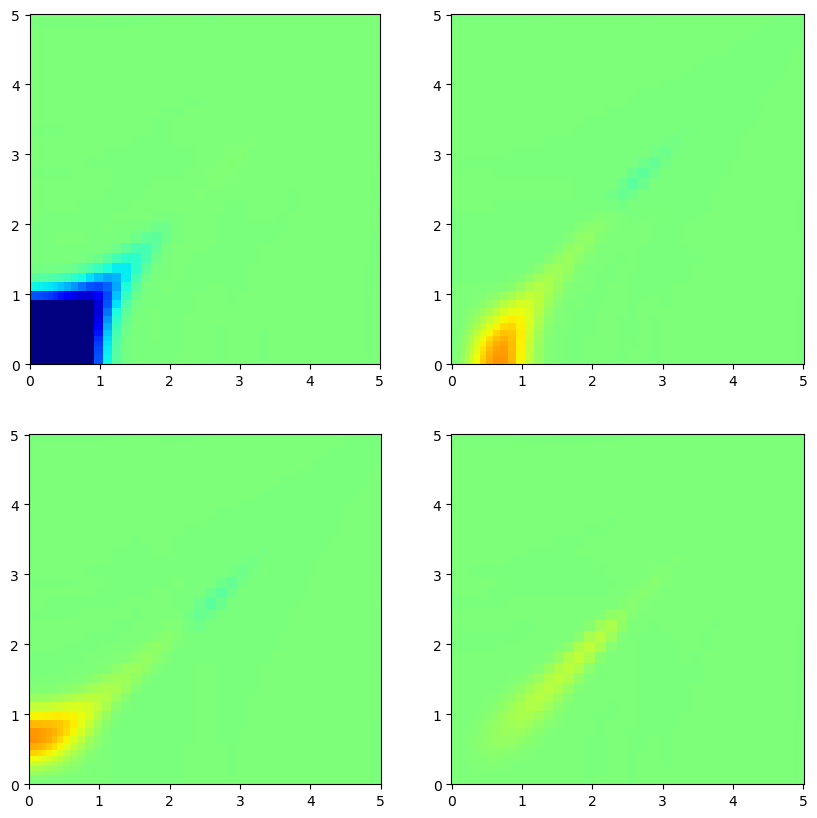

In [13]:
maxindex = Nrows
fig, (ax) = plt.subplots(nrows=2,ncols=2,figsize=(10, 10))
maxabs = max(abs((Vmat/PhaseSpace_coupled)[:maxindex,:maxindex].min()),abs(abs((Vmat/PhaseSpace_coupled)[:maxindex,:maxindex].max())))
ax[0,0].set_aspect('equal')
im = ax[0,0].pcolormesh(mesh_points[:maxindex], mesh_points[:maxindex], (Vmat00_final/PhaseSpace)[:maxindex,:maxindex], vmin = -maxabs, vmax = maxabs, cmap='jet',rasterized=True)
im = ax[0,1].pcolormesh(mesh_points[:maxindex], mesh_points[:maxindex], (Vmat02_final/PhaseSpace)[:maxindex,:maxindex], vmin = -maxabs, vmax = maxabs, cmap='jet',rasterized=True)
im = ax[1,0].pcolormesh(mesh_points[:maxindex], mesh_points[:maxindex], (Vmat20_final/PhaseSpace)[:maxindex,:maxindex], vmin = -maxabs, vmax = maxabs, cmap='jet',rasterized=True)
im = ax[1,1].pcolormesh(mesh_points[:maxindex], mesh_points[:maxindex], (Vmat22_final/PhaseSpace)[:maxindex,:maxindex], vmin = -maxabs, vmax = maxabs, cmap='jet',rasterized=True)

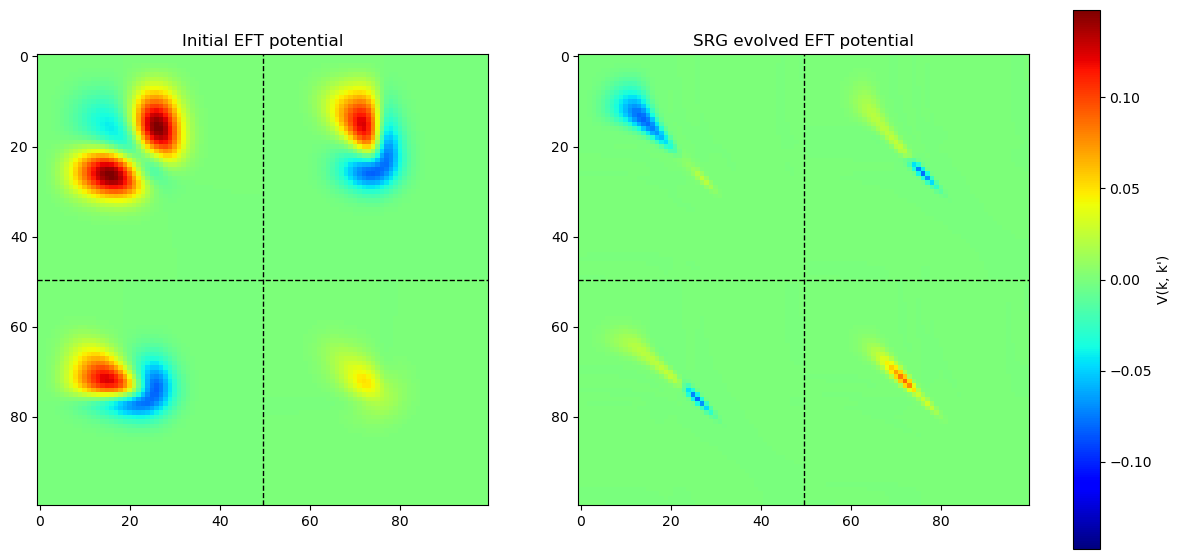

In [14]:
V_full_init = H_init_mat - Tmat_coupled
V_full_final = H_final_mat - Tmat_coupled

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Gemeinsame Farbskala für beide Plots
maxabs = max(abs(V_full_init.min()), abs(V_full_init.max()))

# Plot 1: Initiales Potential (100x100)
im1 = ax1.imshow(V_full_init, vmin=-maxabs, vmax=maxabs, cmap='jet')
ax1.set_title("Initial EFT potential")
# Hilfslinien, um die S- und D-Wellen Blöcke zu markieren
ax1.axhline(y=Nrows-0.5, color='black', linestyle='--', linewidth=1)
ax1.axvline(x=Nrows-0.5, color='black', linestyle='--', linewidth=1)

# Plot 2: Finales Potential nach SRG (100x100)
im2 = ax2.imshow(V_full_final, vmin=-maxabs, vmax=maxabs, cmap='jet')
ax2.set_title(f"SRG evolved EFT potential")
ax2.axhline(y=Nrows-0.5, color='black', linestyle='--', linewidth=1)
ax2.axvline(x=Nrows-0.5, color='black', linestyle='--', linewidth=1)

# Gemeinsame Colorbar
fig.colorbar(im2, ax=[ax1, ax2], label='V(k, k\')', fraction=0.046, pad=0.04)

plt.show()

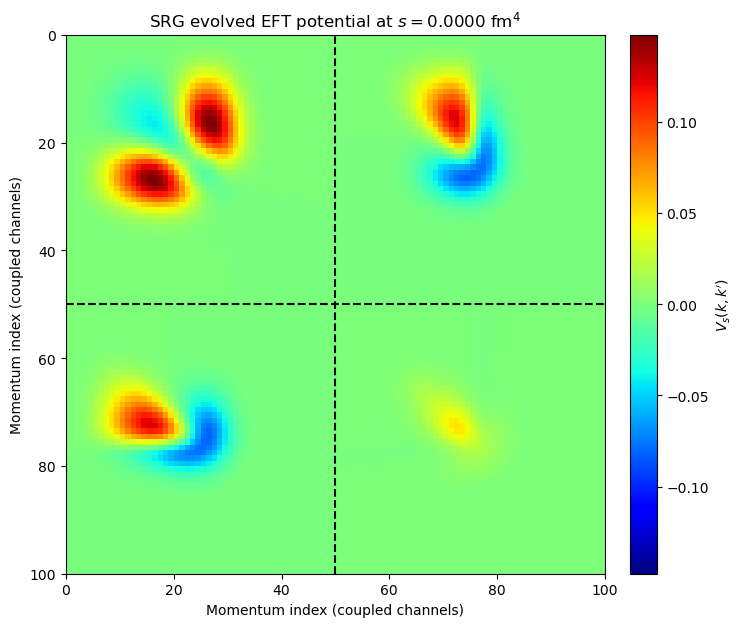

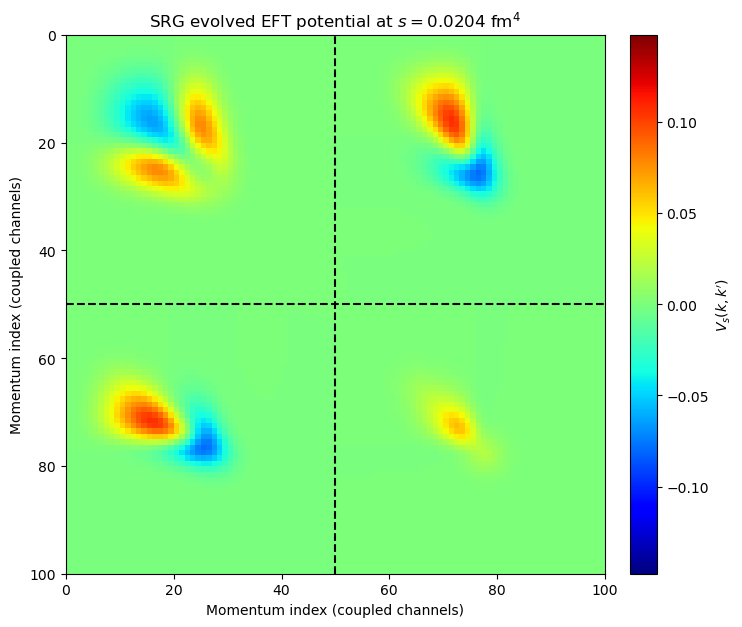

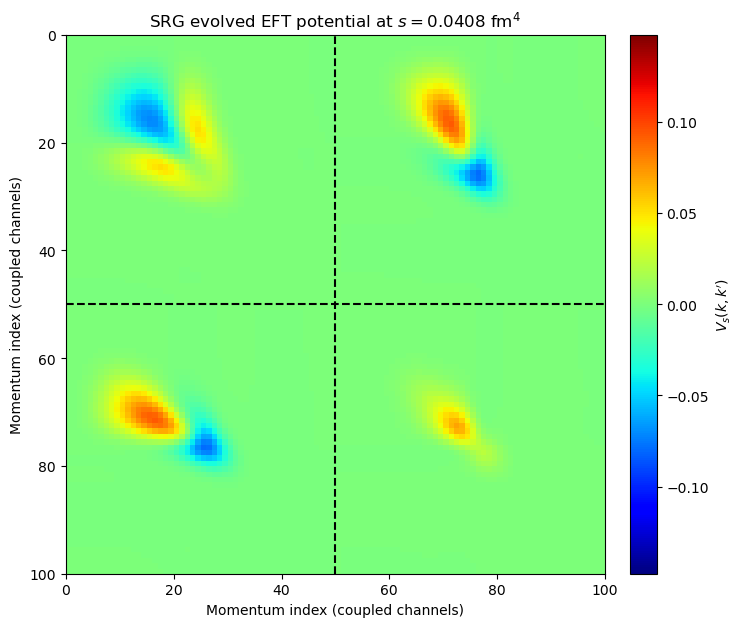

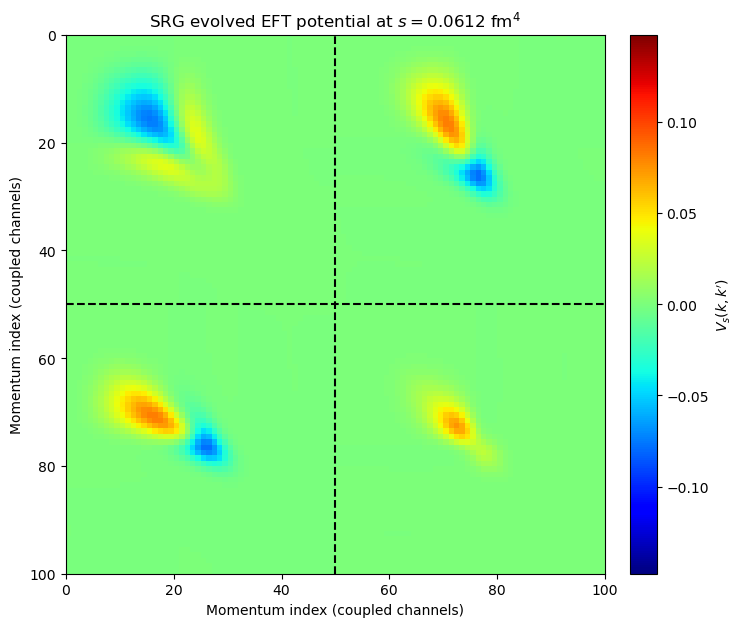

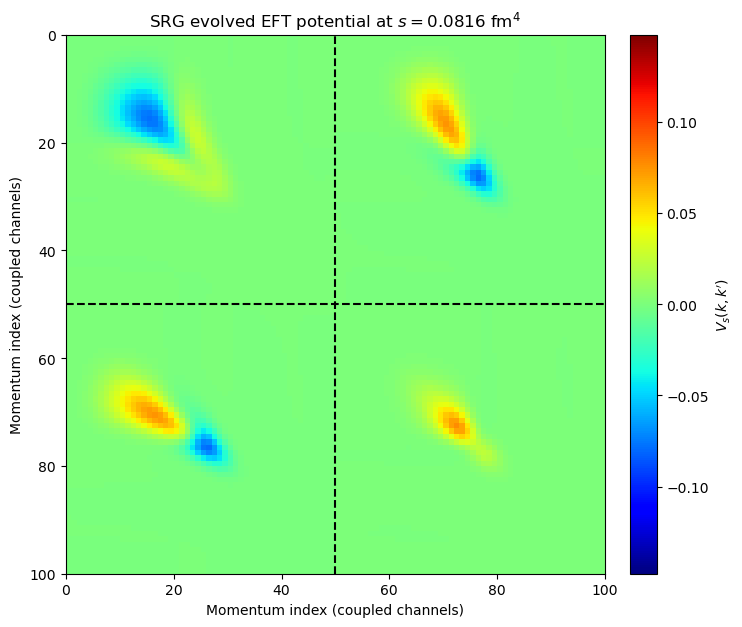

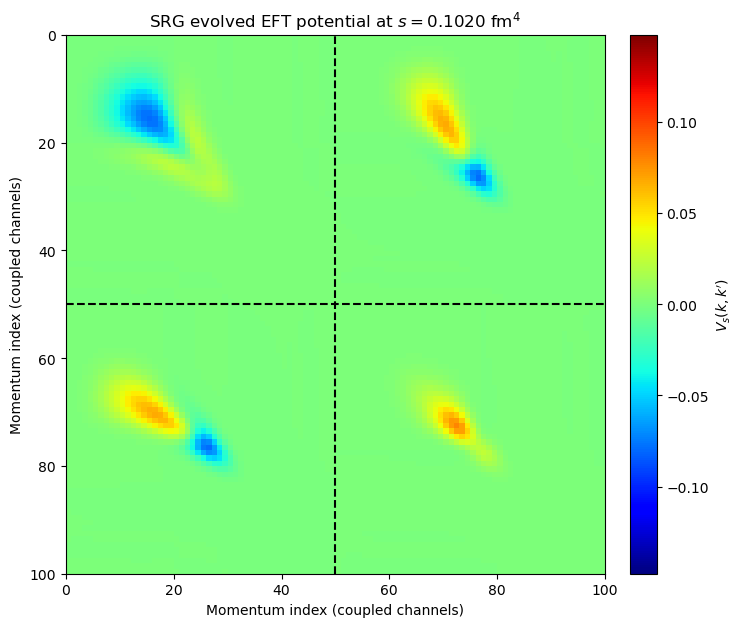

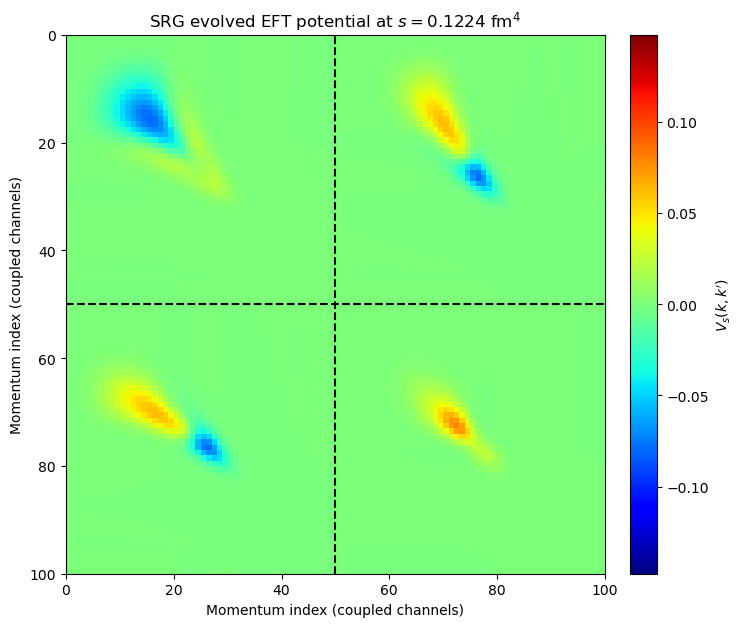

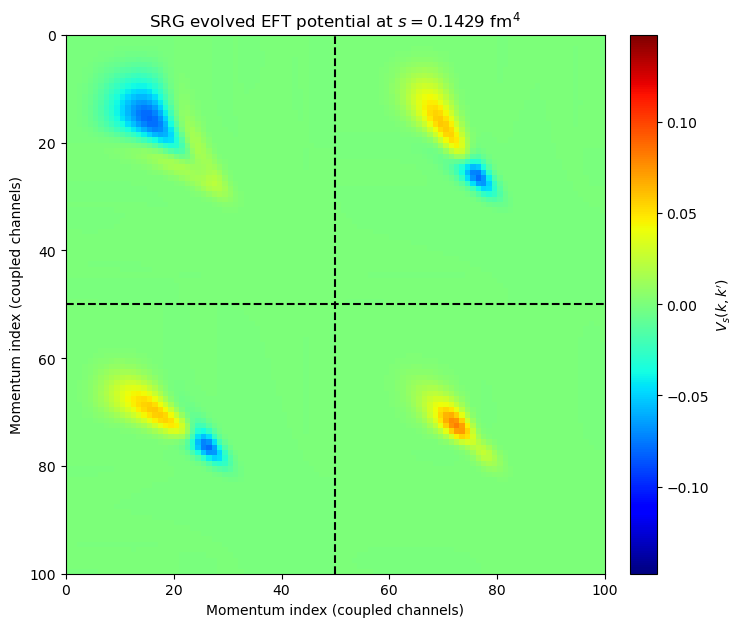

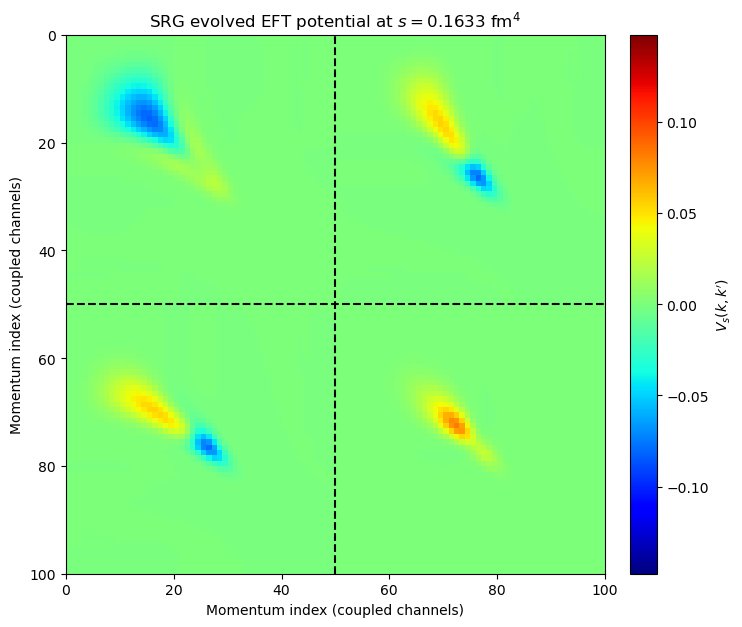

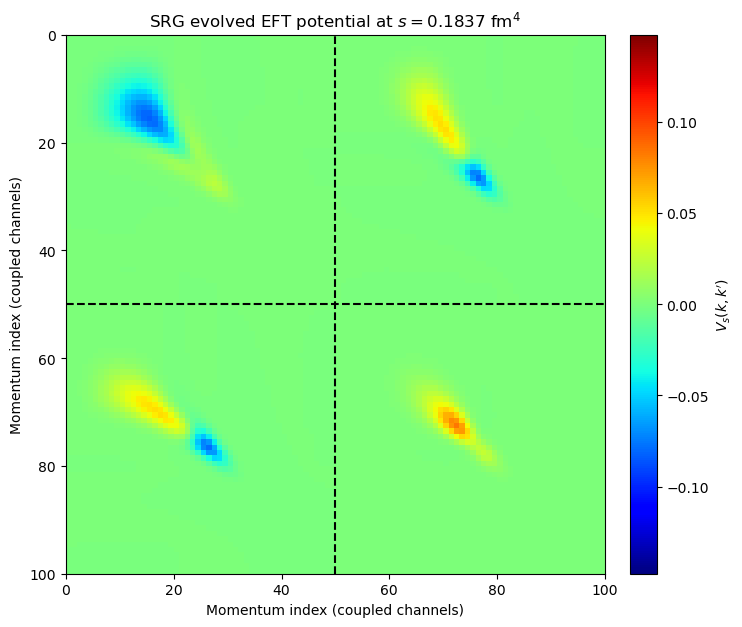

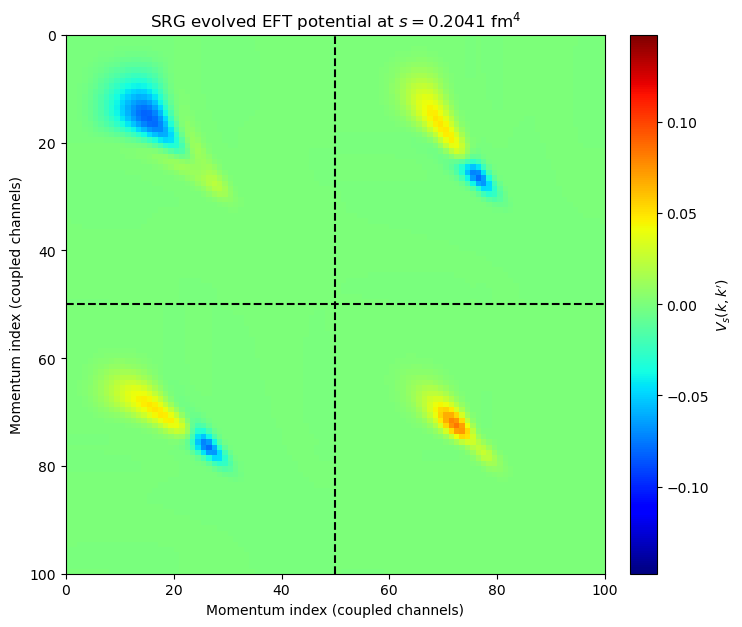

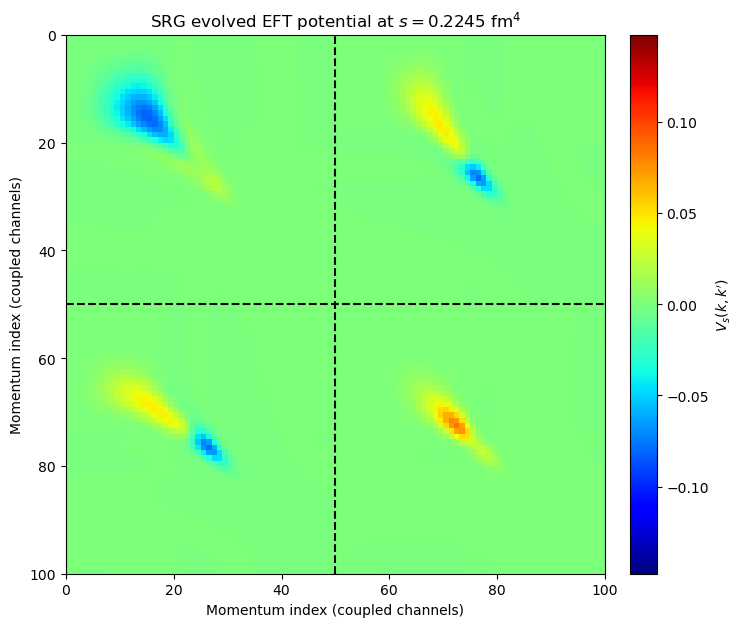

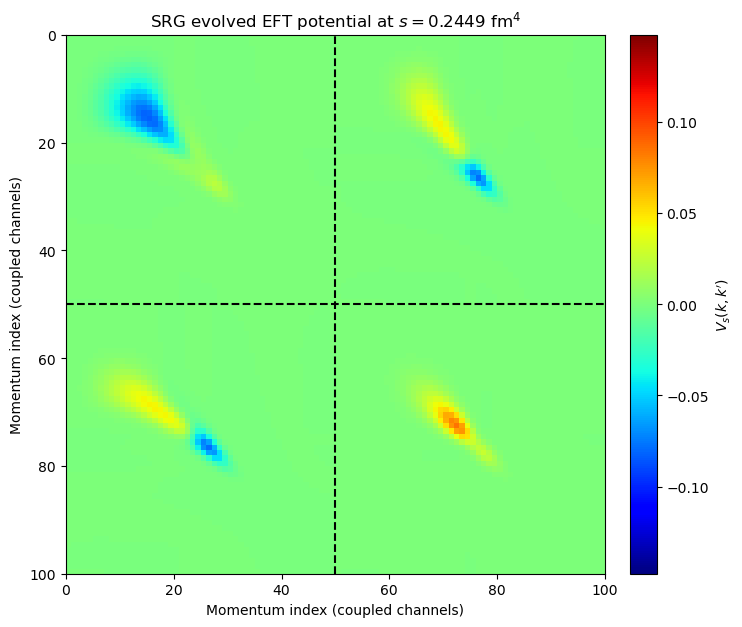

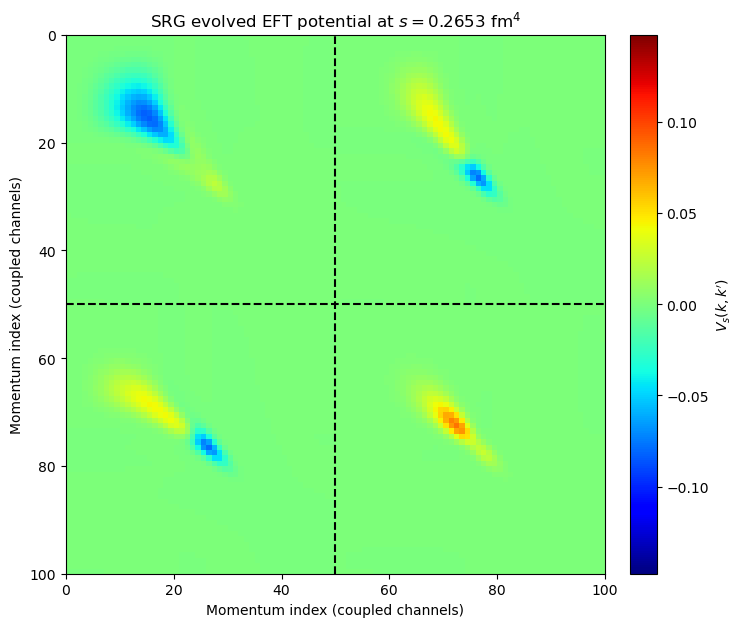

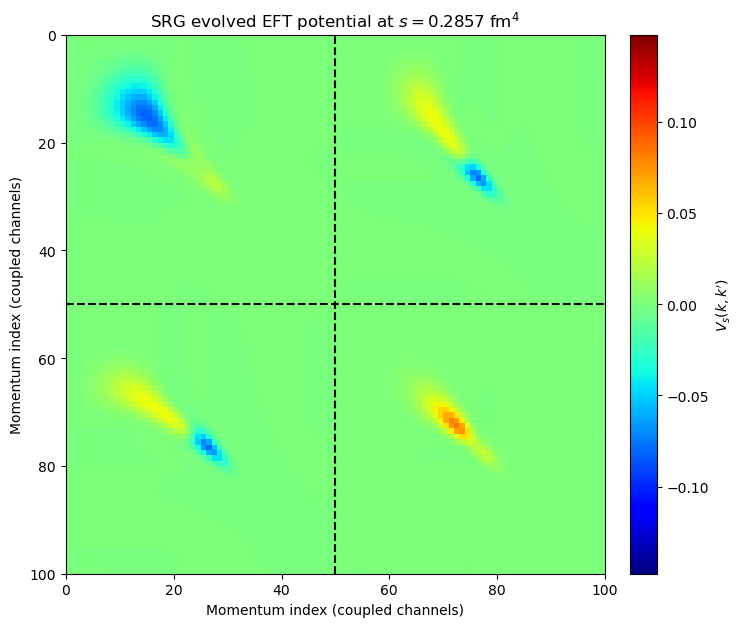

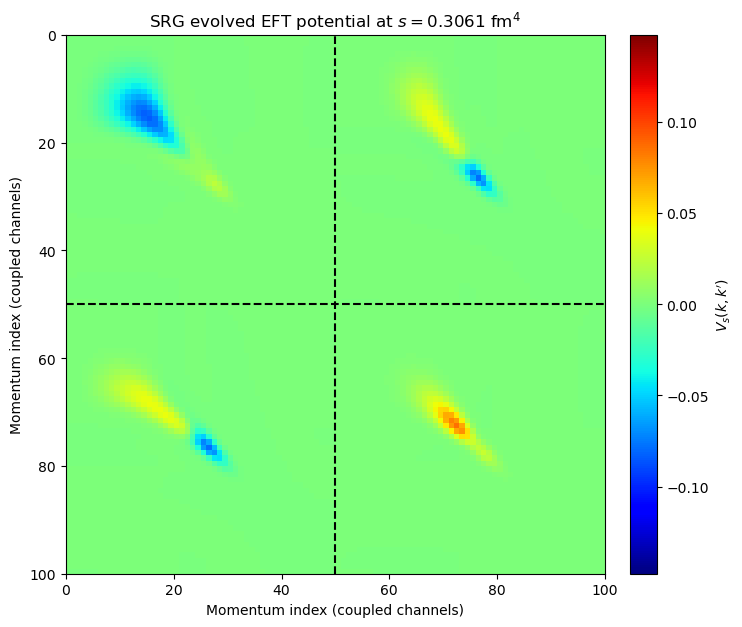

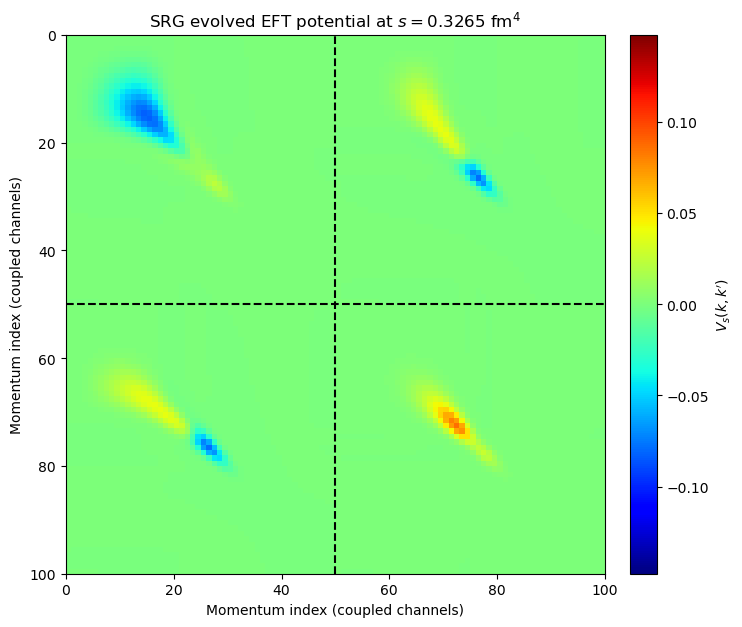

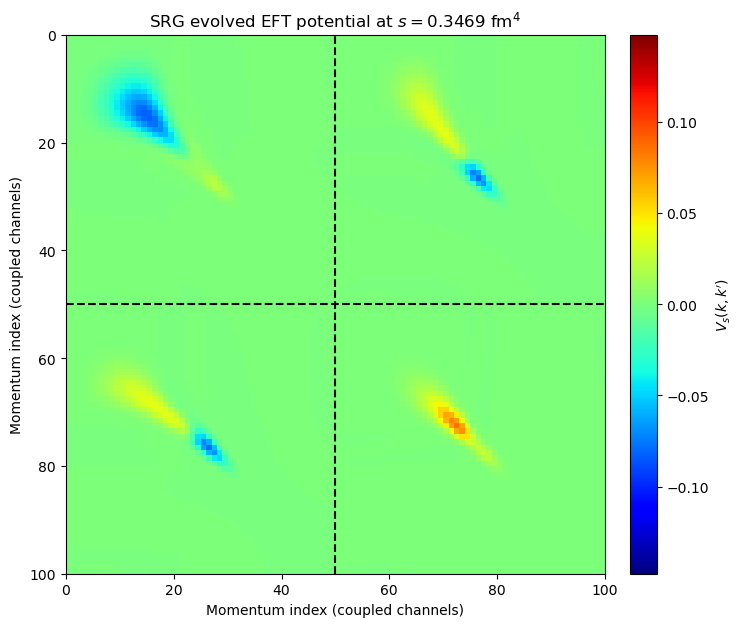

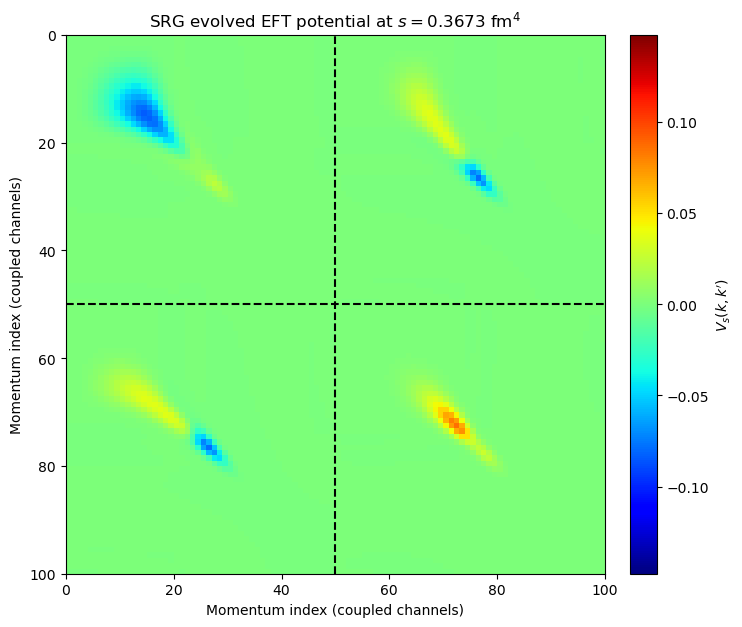

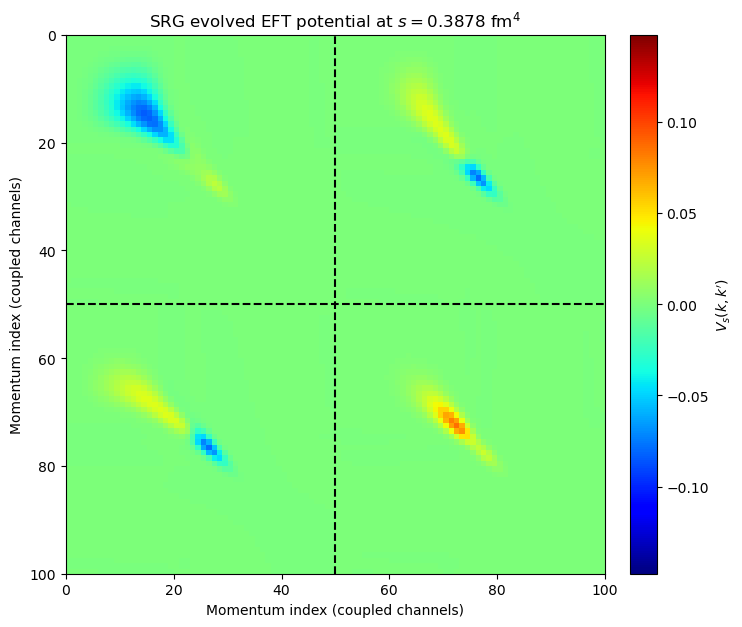

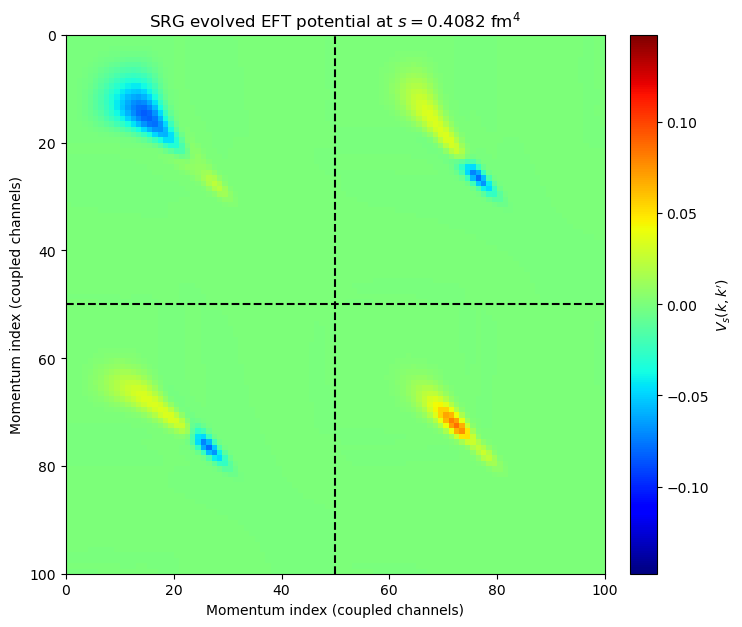

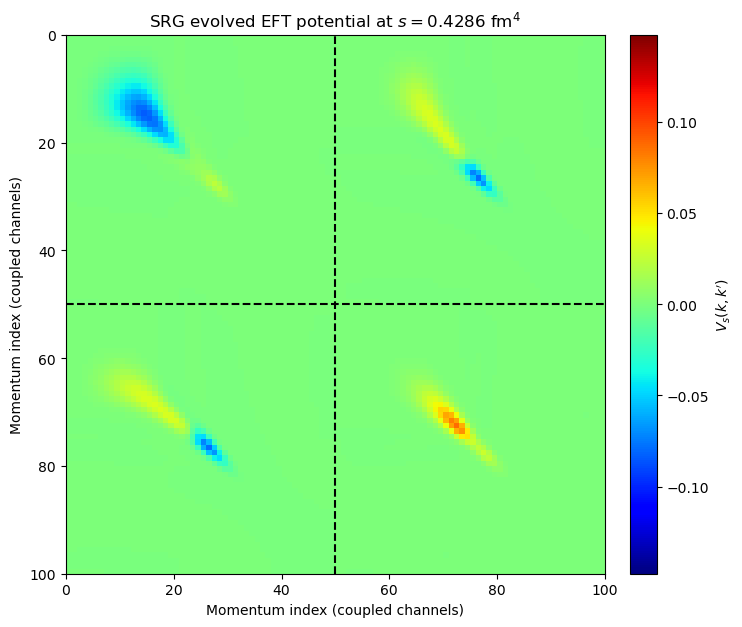

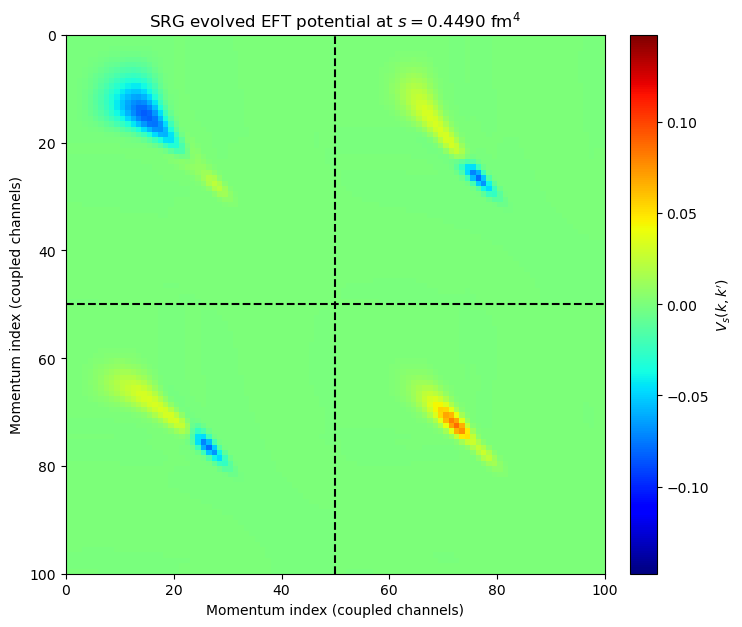

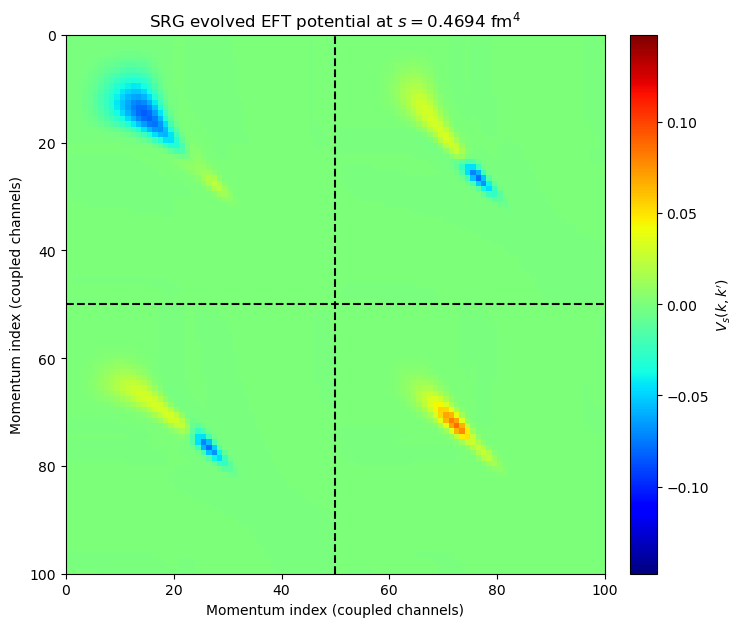

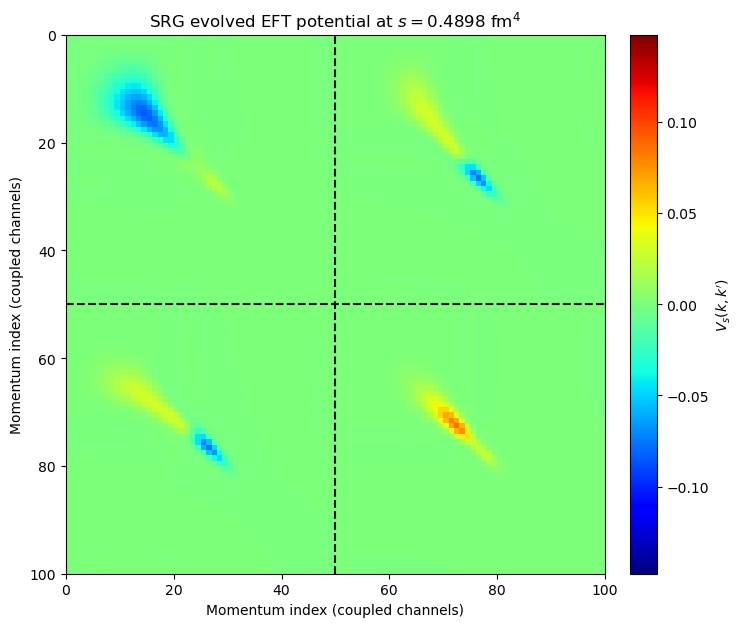

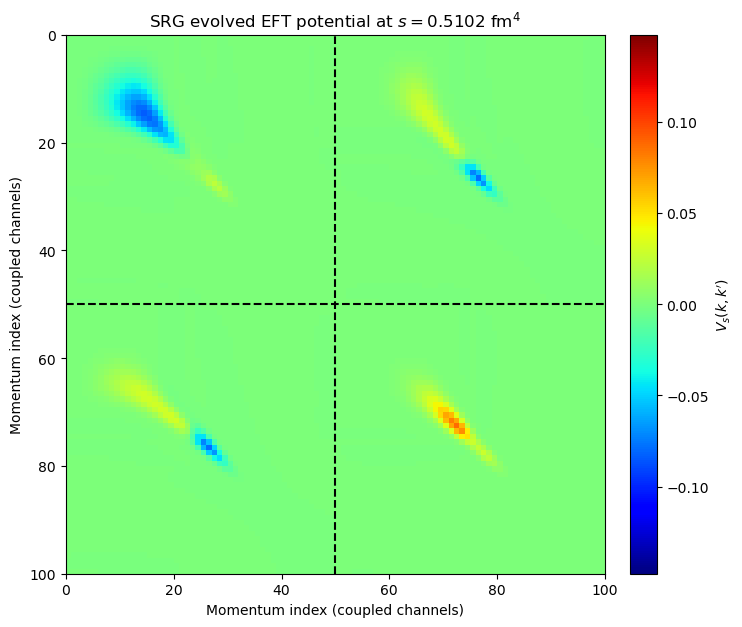

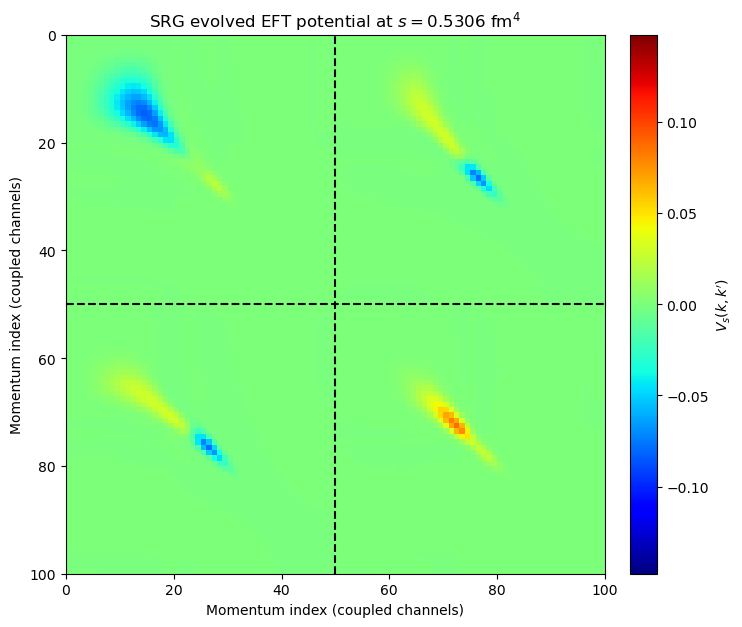

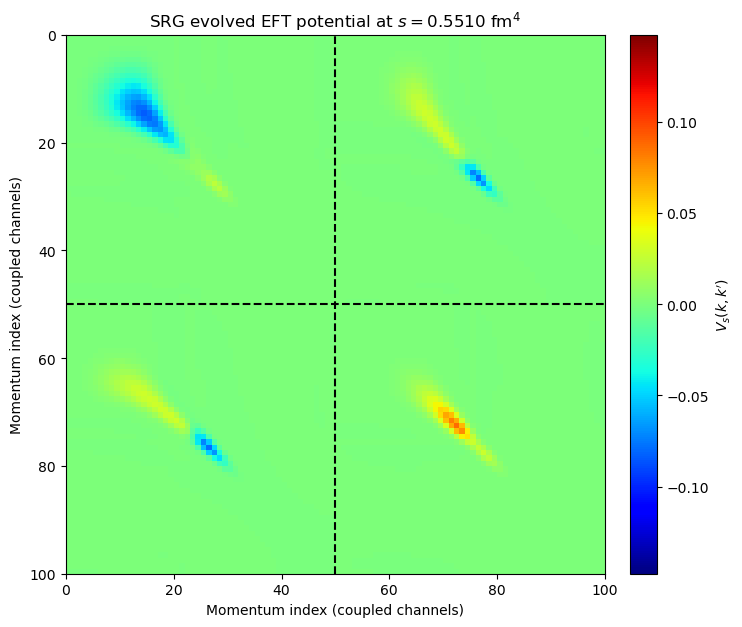

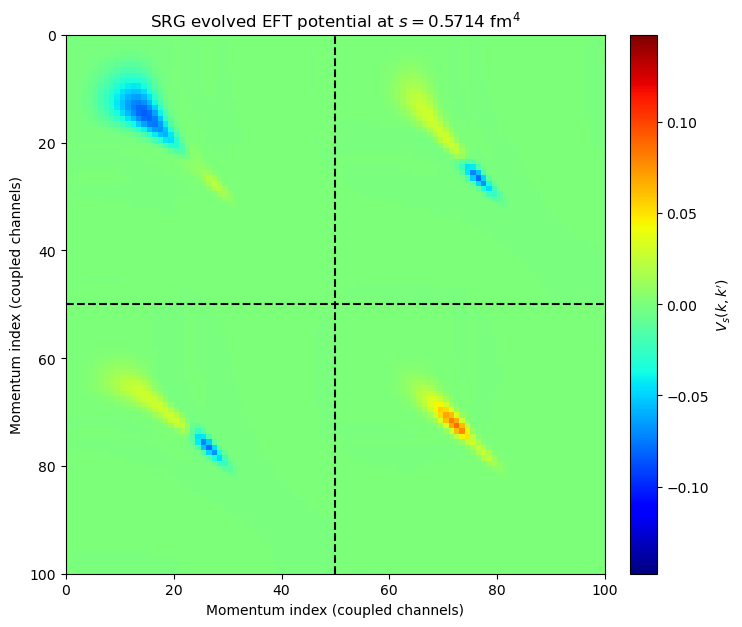

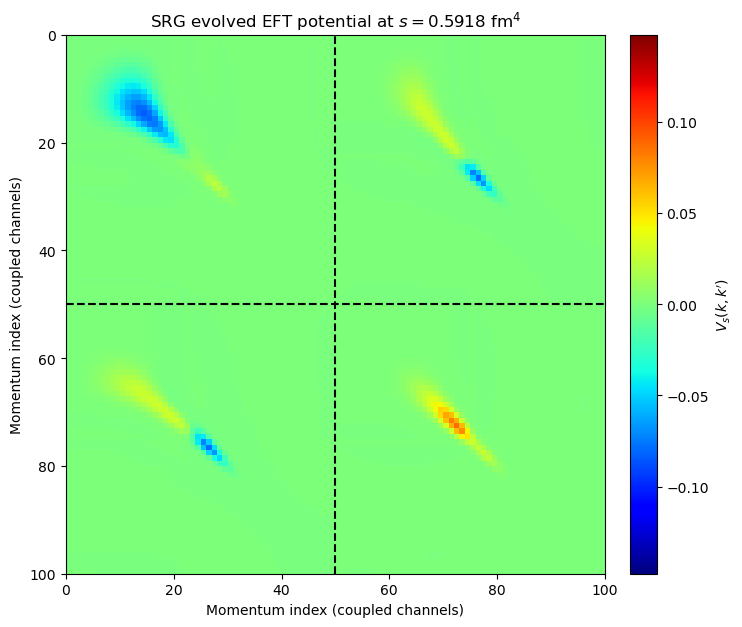

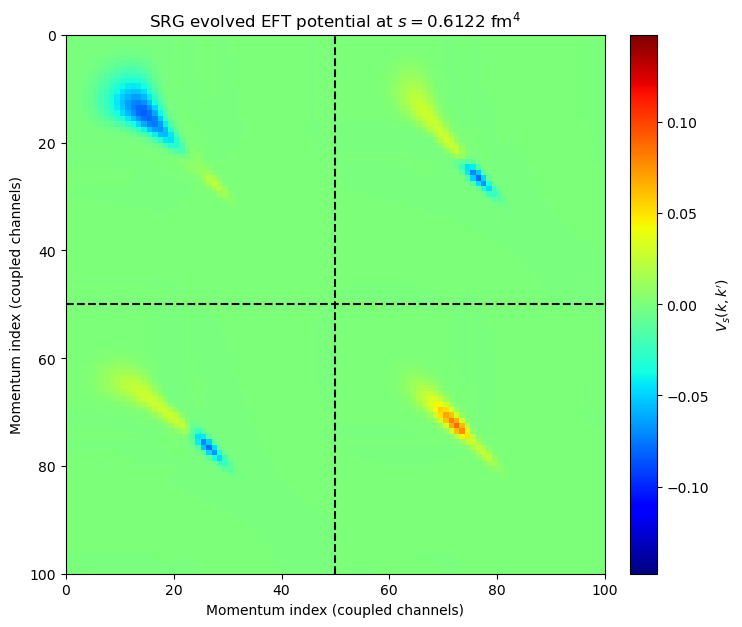

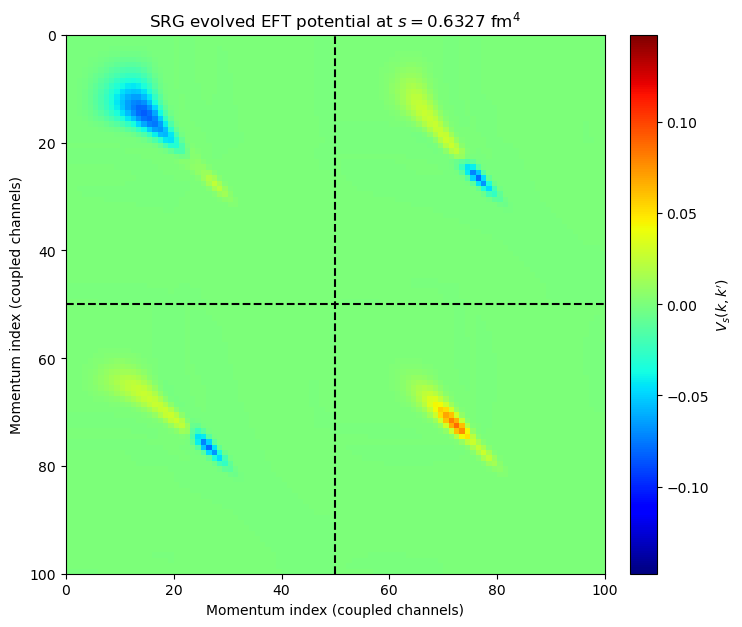

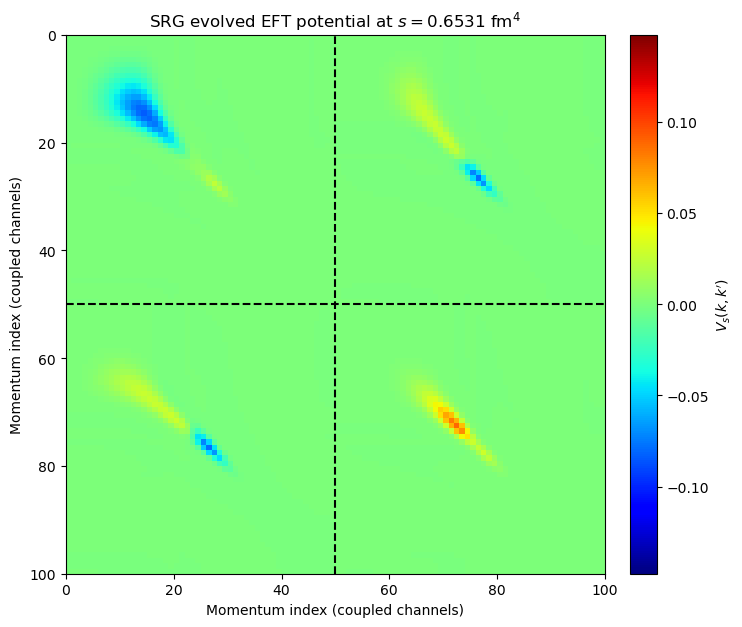

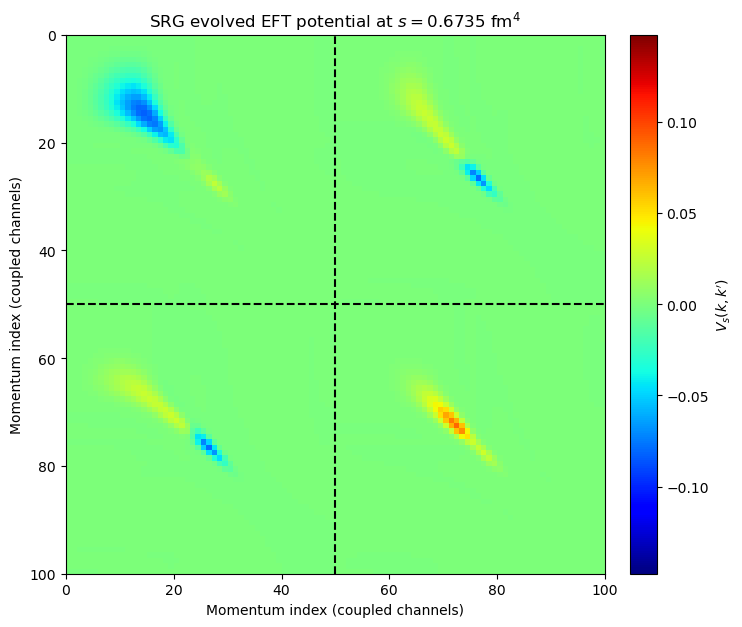

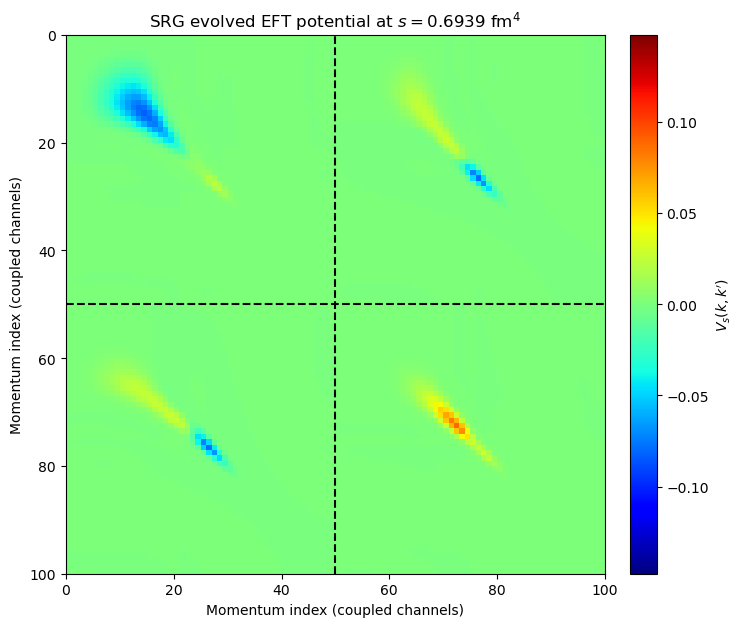

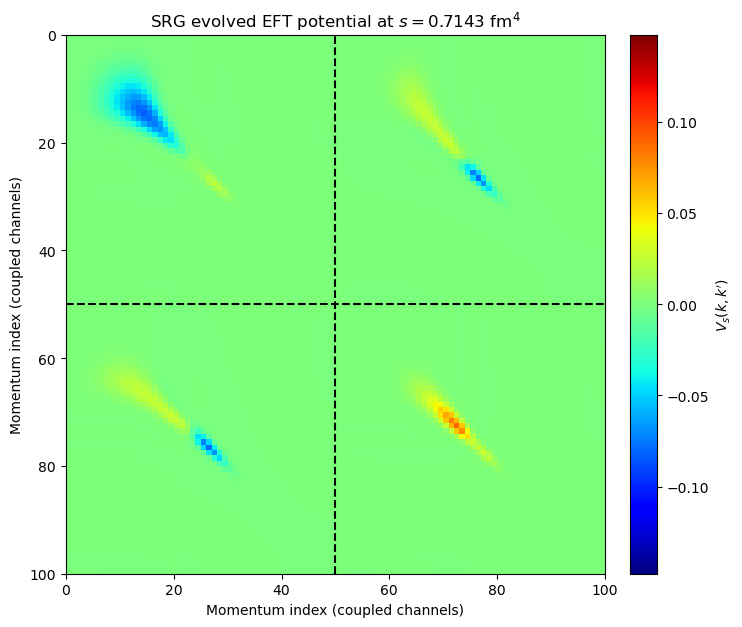

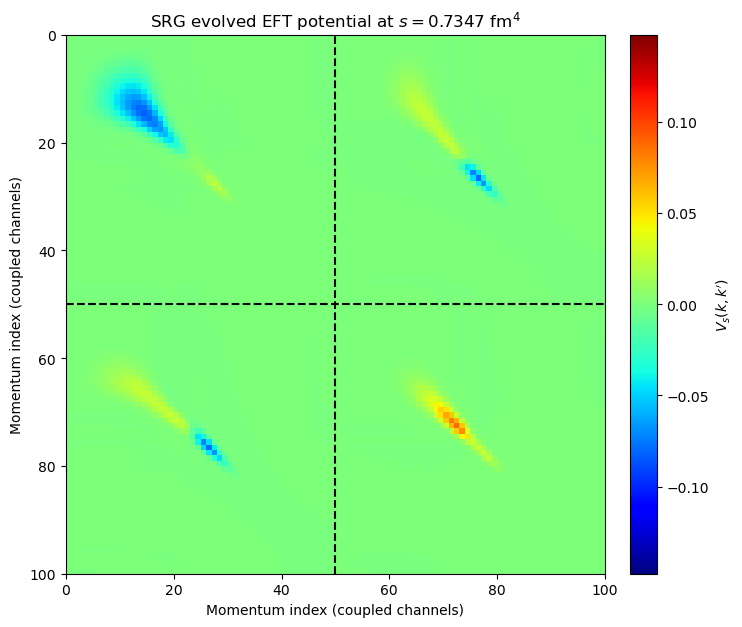

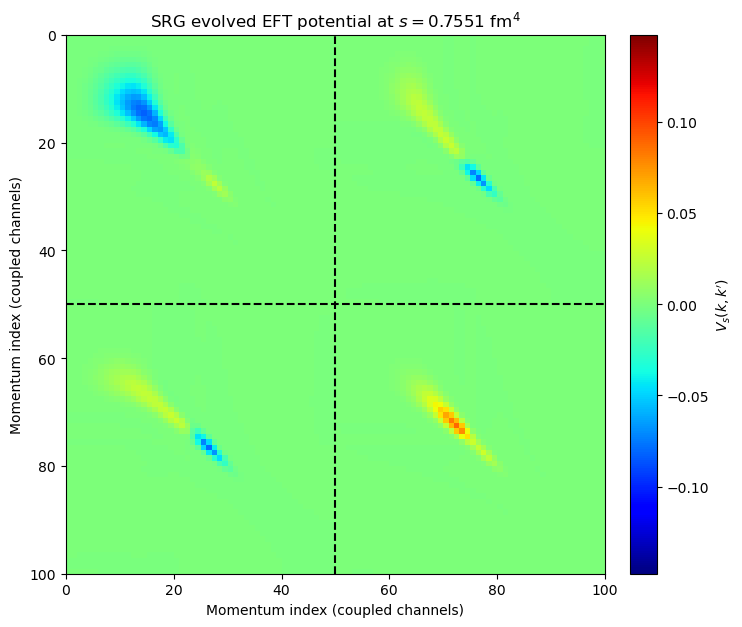

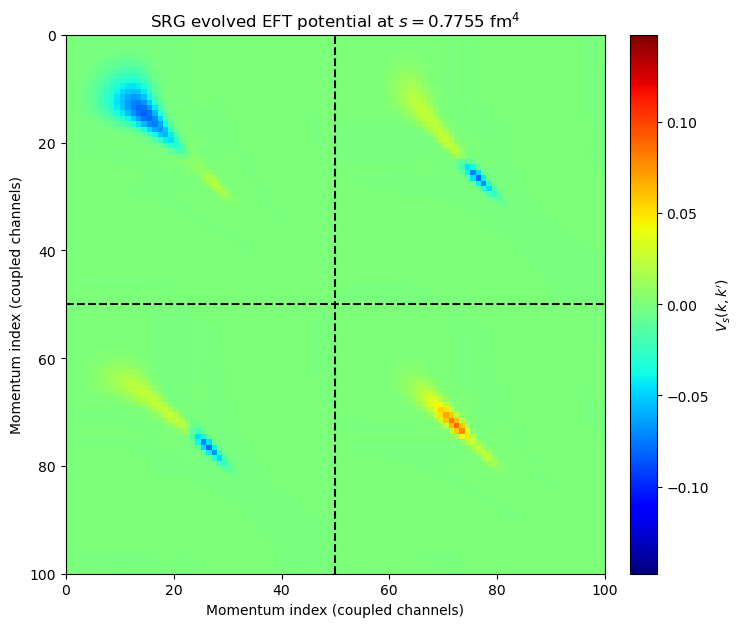

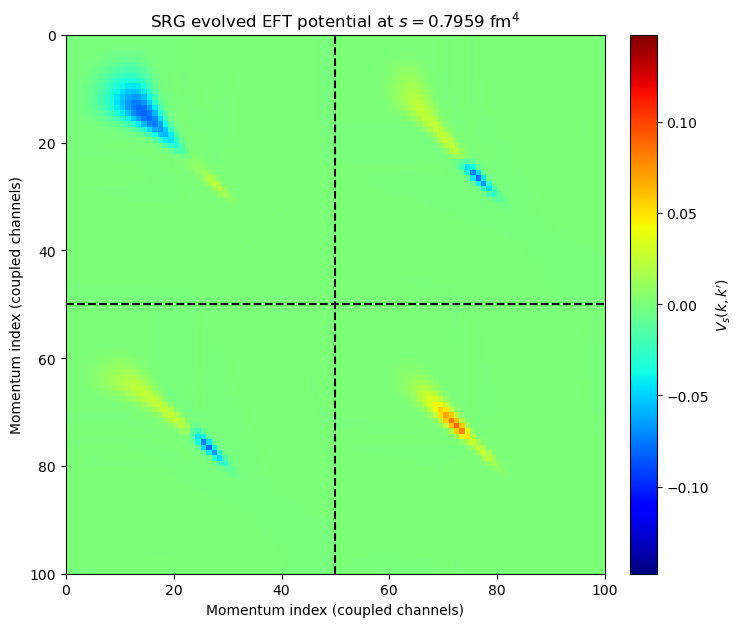

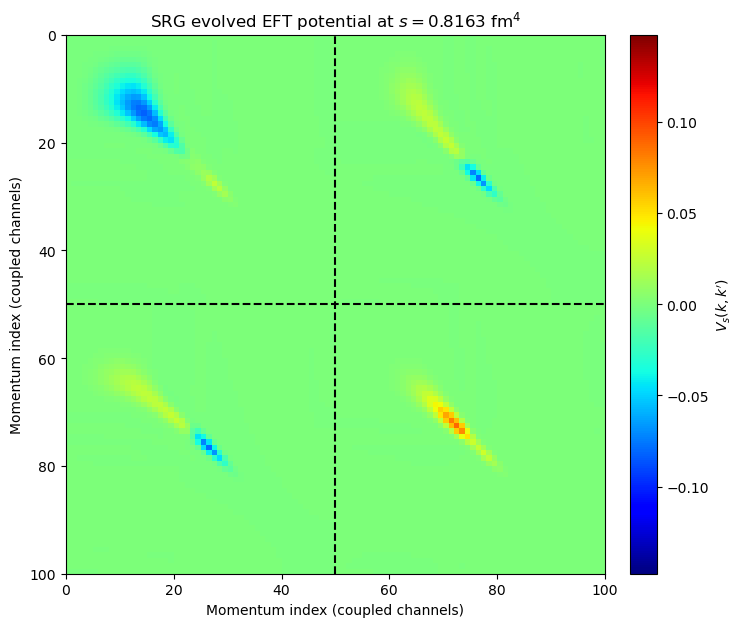

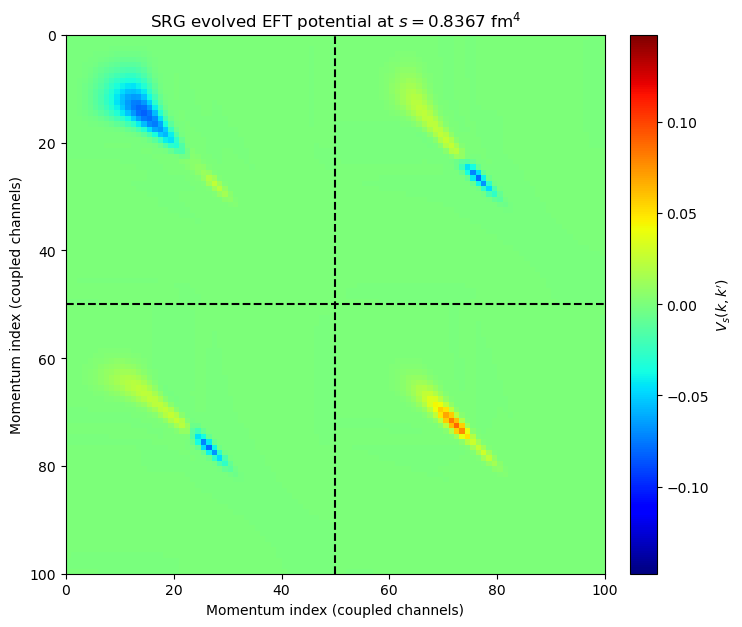

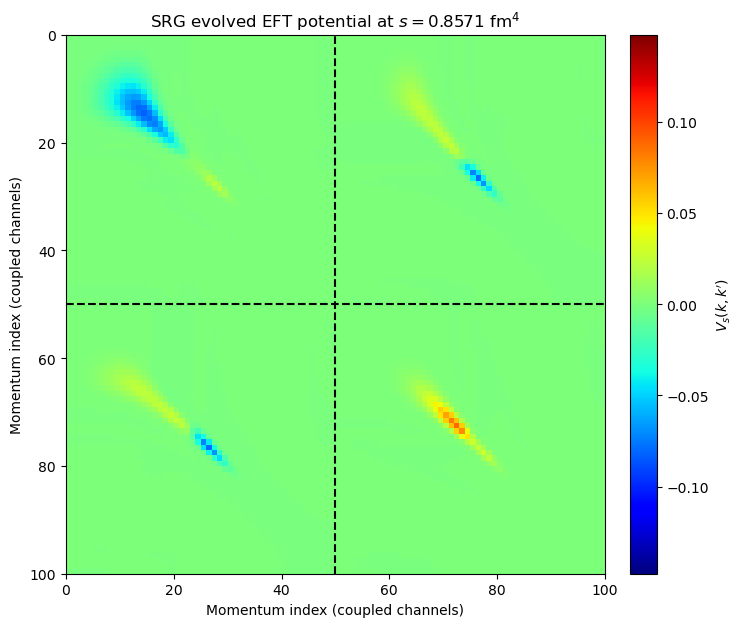

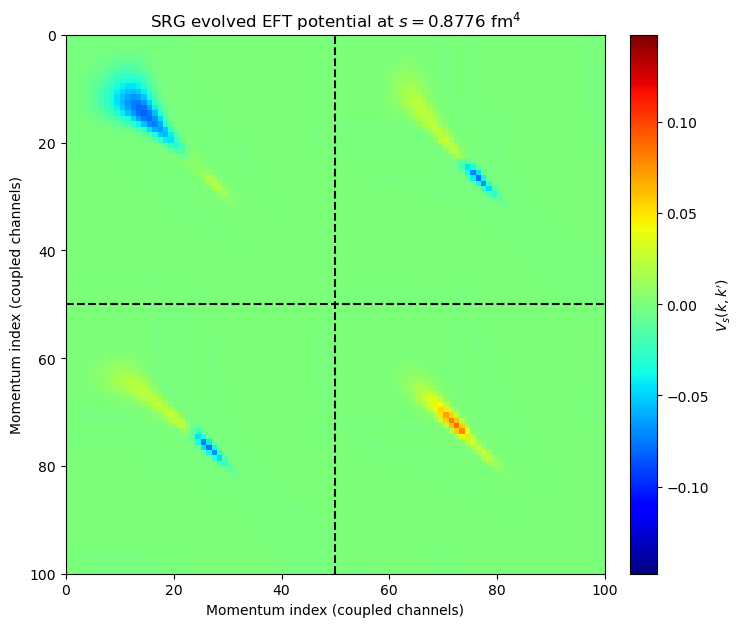

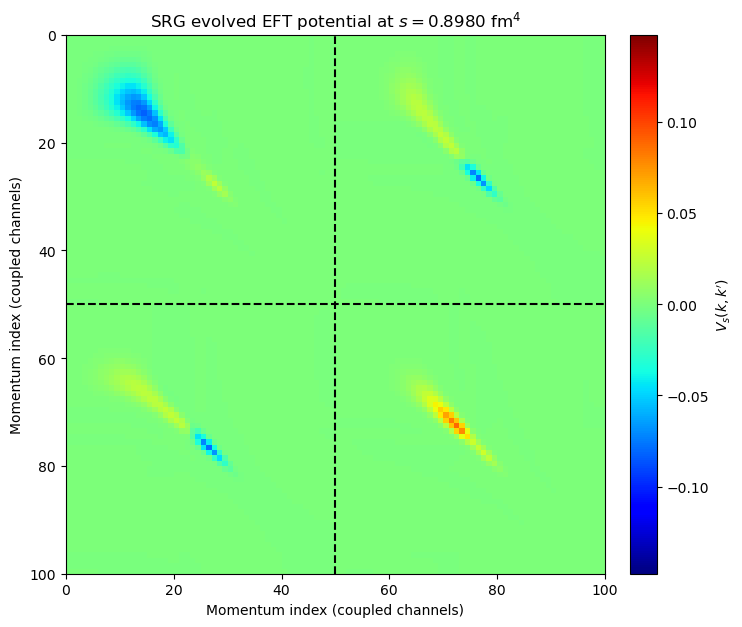

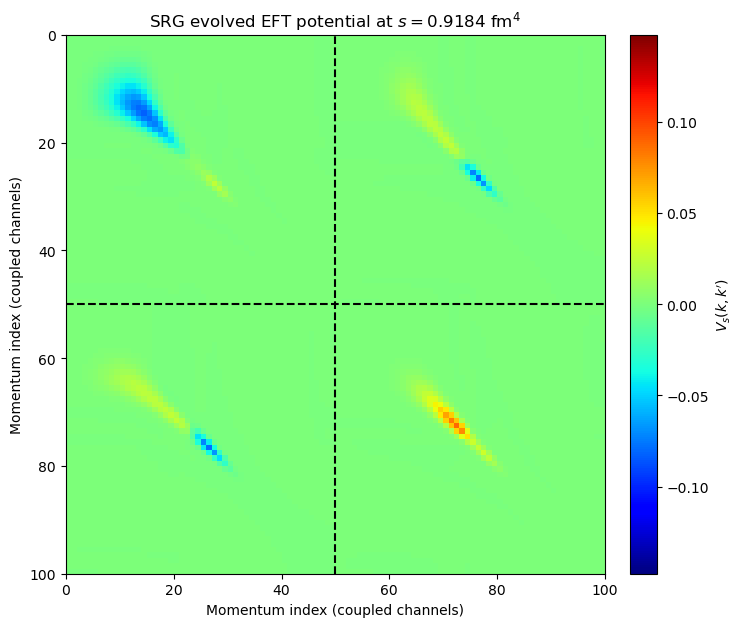

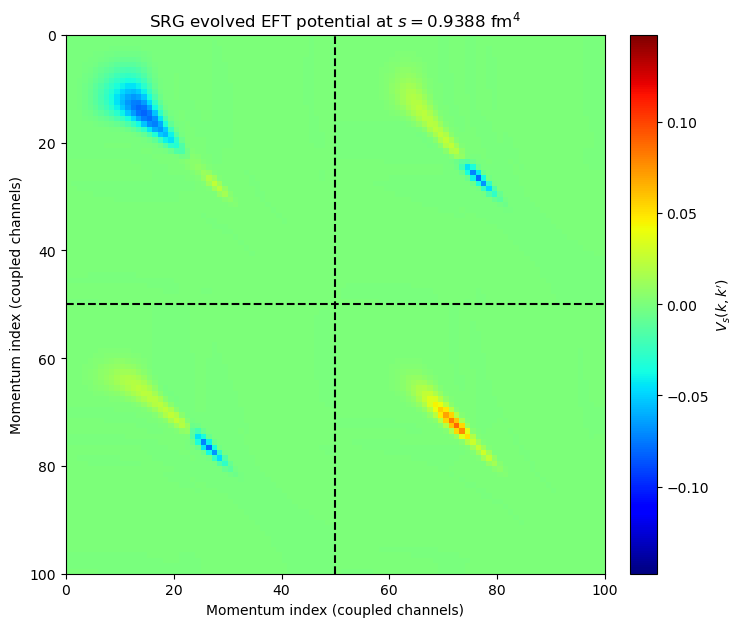

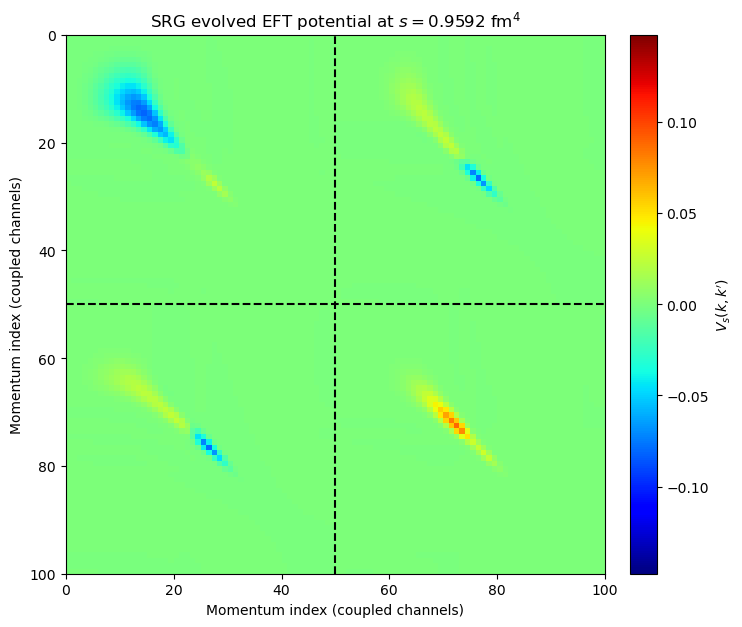

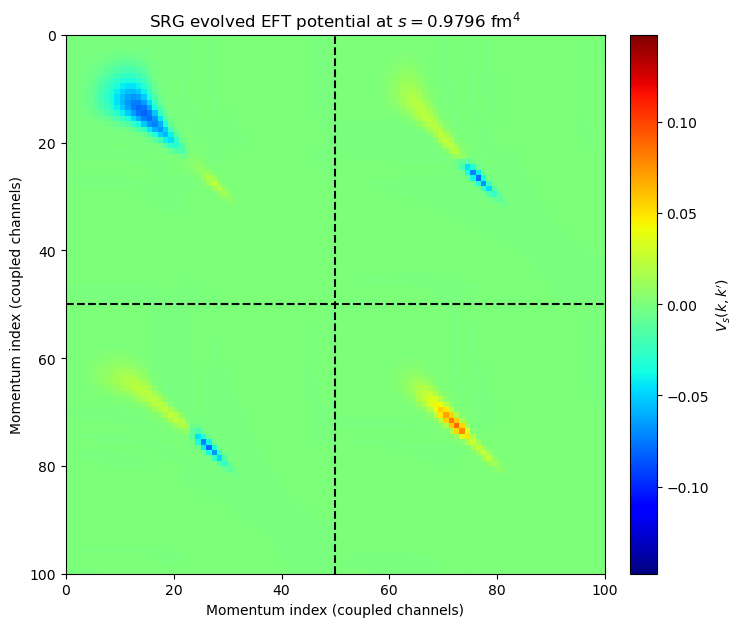

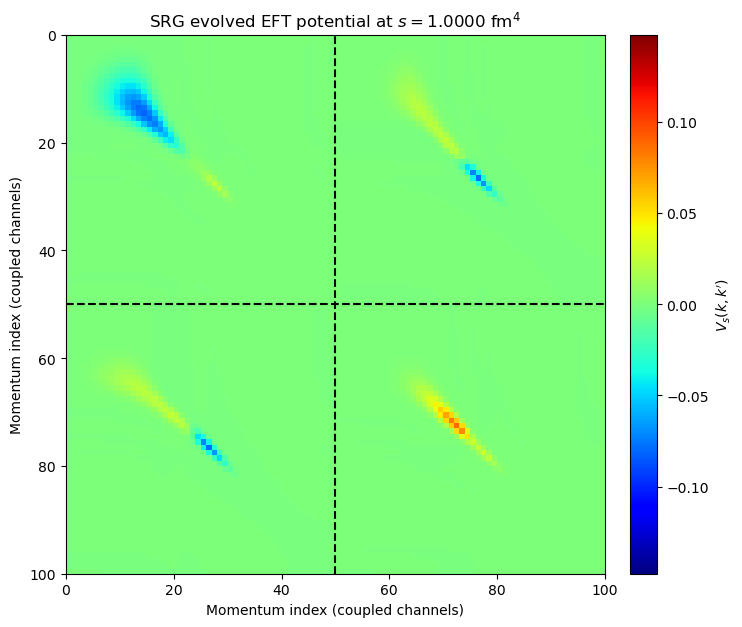

In [15]:
# Berechnung des globalen Maximums für eine konsistente Farbskala
V_initial_check = sol[0].reshape(2*Nrows, 2*Nrows) - Tmat_coupled
vmax_global = np.max(np.abs(V_initial_check))
vmin_global = -vmax_global

# Loop über alle berechneten Schritte des Flussparameters s
for idx, s_val in enumerate(s_steps):
    # Extrahiere H(s) und berechne V(s) = H(s) - T
    H_s_flat = sol[idx]
    H_s_mat = H_s_flat.reshape(2*Nrows, 2*Nrows)
    V_s_mat = H_s_mat - Tmat_coupled
    
    # Erstellung des Einzelfigure-Plots
    fig, ax = plt.subplots(figsize=(8, 7))
    
    im = ax.imshow(V_s_mat, vmin=vmin_global, vmax=vmax_global, cmap='jet', extent=[0, 2*Nrows, 2*Nrows, 0])
    
    # Titel mit aktuellem s-Wert
    ax.set_title(f"SRG evolved EFT potential at $s = {s_val:.4f}$ fm$^4$")
    
    # Hilfslinien zur Trennung der Kanäle (S- und D-Wellen)
    ax.axhline(y=Nrows, color='black', linestyle='--', linewidth=1.5)
    ax.axvline(x=Nrows, color='black', linestyle='--', linewidth=1.5)
    
    # Achsenbeschriftung (optional, je nach Bedarf)
    ax.set_xlabel("Momentum index (coupled channels)")
    ax.set_ylabel("Momentum index (coupled channels)")
    
    # Colorbar hinzufügen
    fig.colorbar(im, ax=ax, label="$V_s(k, k')$", fraction=0.046, pad=0.04)
    
    plt.show()
    
    # Hinweis: Falls die Ausgabe zu viele Bilder erzeugt, 
    # kann man plt.close(fig) nutzen oder nur jeden n-ten Schritt plotten.